In [25]:
from get_noise_sigma import load_dataset

dataset_name = ['TIMIT-sentence_type-16k', 'TIMIT-gender-16k', 'TIMIT-dialect-16k']
dataset_name = ['TIMIT-sentence_type-16k']
for dataset in dataset_name:
    data = load_dataset(dataset)

    import numpy as np 
    key1 = 'TRAIN'
    audio = {key1: {}}
    for key2 in data[key1].keys():
        audio[key1][key2] = {}
        for key3 in data[key1][key2].keys():
            l = [(10 ** (i / 10)).sum(axis=-1).mean() for i in data[key1][key2][key3]]
            audio[key1][key2][key3] = l
            if "FJSP0" in key3:
                d = [i for i in data[key1][key2][key3]]
                size_l = [[i.shape for i in data[key1][key2][key3]]]
                # print(l, np.mean(l), np.std(l))
                
                if len(size_l)>0:
                    print(l)
                    print(size_l)
    # audio

    key1 = 'TRAIN'
    s = []
    for key2 in audio[key1].keys():
        for key3 in audio[key1][key2].keys():
            s.append(np.mean(audio[key1][key2][key3]))
    np.mean(s)

    from get_noise_sigma import get_gaussian_sigma
    print(f'=========={dataset}==========')
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -20))
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -15))
    print("H, 0dB:", get_gaussian_sigma(np.mean(s), 0))
    print("M, 15dB:", get_gaussian_sigma(np.mean(s), 15)) 
    print("L, 25dB:", get_gaussian_sigma(np.mean(s), 25))

[0.5865394, 0.67150676, 0.47556317, 0.4730428, 0.56988645, 0.5005794, 0.3759934, 0.15124355, 0.61658335, 0.53292525]
[[(1, 439, 64), (1, 289, 64), (1, 124, 64), (1, 383, 64), (1, 289, 64), (1, 347, 64), (1, 269, 64), (1, 251, 64), (1, 358, 64), (1, 274, 64)]]
==========TIMIT-sentence_type-16k==========
H, -15dB: 5.2243327129946735
H, -15dB: 2.9378581810607165
H, 0dB: 0.5224332712994674
M, 15dB: 0.09290323294711213
L, 25dB: 0.029378581810607162


In [31]:
for i in range(-50, 25, 5):
    print(i)

-50
-45
-40
-35
-30
-25
-20
-15
-10
-5
0
5
10
15
20


In [21]:
import numpy as np 

d = np.load('autrainer-configurations/data/TIMIT-sentence_type/log_mel_16k/TRAIN/DR1/FJSP0/SI1763.npy')
d.shape

(1, 124, 64)

In [7]:
data[key1][key2][key3][0]

array([[[-66.63042 , -73.305824, -71.27079 , ..., -74.84277 ,
         -75.548836, -73.677795],
        [-69.301056, -70.75253 , -73.69812 , ..., -77.08617 ,
         -75.10583 , -76.025406],
        [-64.58675 , -68.39219 , -71.196365, ..., -77.14436 ,
         -74.91669 , -75.98715 ],
        ...,
        [-70.7788  , -72.53138 , -74.578674, ..., -76.77527 ,
         -79.664825, -78.050415],
        [-64.76122 , -67.40239 , -69.33204 , ..., -77.51434 ,
         -79.49958 , -75.39704 ],
        [-69.98446 , -67.58452 , -63.267235, ..., -76.53399 ,
         -72.48188 , -71.63718 ]]], dtype=float32)

In [12]:
(10 ** (data[key1][key2][key3][0] / 10)).max()

0.04616595

In [15]:
data[key1][key2][key3][0]

array([[[-66.63042 , -73.305824, -71.27079 , ..., -74.84277 ,
         -75.548836, -73.677795],
        [-69.301056, -70.75253 , -73.69812 , ..., -77.08617 ,
         -75.10583 , -76.025406],
        [-64.58675 , -68.39219 , -71.196365, ..., -77.14436 ,
         -74.91669 , -75.98715 ],
        ...,
        [-70.7788  , -72.53138 , -74.578674, ..., -76.77527 ,
         -79.664825, -78.050415],
        [-64.76122 , -67.40239 , -69.33204 , ..., -77.51434 ,
         -79.49958 , -75.39704 ],
        [-69.98446 , -67.58452 , -63.267235, ..., -76.53399 ,
         -72.48188 , -71.63718 ]]], dtype=float32)

In [2]:
import autrainer 
autrainer.__file__

KeyboardInterrupt: 

In [7]:
np.mean(s)

0.27293652

In [6]:
snr_db = 0
(10 ** (snr_db/10))

1.0

In [33]:
key1 = 'TRAIN'
db = []
for key2 in audio[key1].keys():
    for key3 in audio[key1][key2].keys():
        db.append(10 * np.log10(np.array(audio[key1][key2][key3]) / 0.2729))
np.concatenate(db).mean()

-1.9086657

In [10]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', "GaussianNoise(H)", "GaussianNoise(L)"]
for train_post in post:
    for test_post in post:
        path = f'./results/noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_{train_post}_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(train_post, test_post, data['f1']['all'])

GaussianNoise(neg20) GaussianNoise(neg20) 0.7138454800834301
GaussianNoise(neg20) GaussianNoise(H) 0.4678583546919213
GaussianNoise(neg20) GaussianNoise(L) 0.4726268895058703
GaussianNoise(H) GaussianNoise(neg20) 0.4092137087915915
GaussianNoise(H) GaussianNoise(H) 0.7427364436748221
GaussianNoise(H) GaussianNoise(L) 0.7408558179385314
GaussianNoise(L) GaussianNoise(neg20) 0.12900346626573586
GaussianNoise(L) GaussianNoise(H) 0.73035910687168
GaussianNoise(L) GaussianNoise(L) 0.7363988916054165


In [11]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', 'GaussianNoise(H)', "GaussianNoise(L)"]
# datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
datasets = ['TIMIT-sentencetype-16k']
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/noise/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data['f1']['all'])  

=====TIMIT-sentencetype-16k=====
GaussianNoise(neg20) 0.29222265004359355
=====TIMIT-sentencetype-16k=====
GaussianNoise(H) 0.7161862794284763
=====TIMIT-sentencetype-16k=====
GaussianNoise(L) 0.7402195443881782


In [9]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', 'GaussianNoise(H)', "GaussianNoise(L)"]
# datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
datasets = ['TIMIT-sentencetype-16k']
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/clean/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_None_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data)  

=====TIMIT-sentencetype-16k=====
GaussianNoise(neg20) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}
=====TIMIT-sentencetype-16k=====
GaussianNoise(H) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}
=====TIMIT-sentencetype-16k=====
GaussianNoise(L) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}


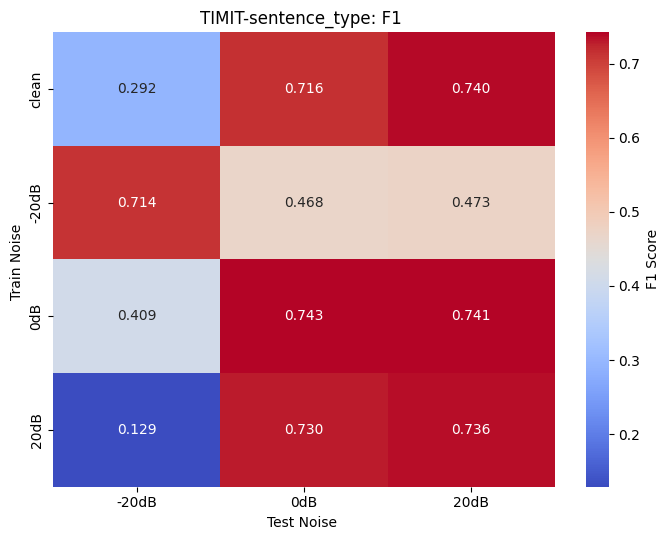

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 定义数据
train_conditions = ["clean", "-20dB", "0dB", "20dB"]
test_conditions = ["-20dB", "0dB", "20dB"]


# 添加干净训练的测试结果
values = np.array([
    [0.29222265004359355, 0.7161862794284763, 0.7402195443881782],  # Clean train
    [0.7138454800834301, 0.4678583546919213, 0.4726268895058703],    # Gaussian(neg20) train
    [0.4092137087915915, 0.7427364436748221, 0.7408558179385314],    # Gaussian(H) train
    [0.12900346626573586, 0.73035910687168, 0.7363988916054165]      # Gaussian(L) train
])

# 画heatmap
plt.figure(figsize=(7, 5.5))
sns.heatmap(values, annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=test_conditions, yticklabels=train_conditions,
            cbar_kws={'label': 'F1 Score'})

plt.title("TIMIT-sentence_type: F1 ")
plt.xlabel("Test Noise ")
plt.ylabel("Train Noise ")
plt.tight_layout()
plt.show()


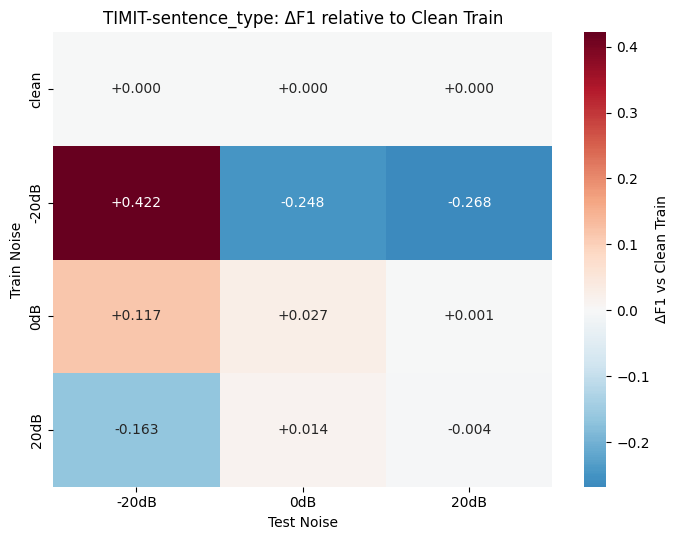


横纵比较分析：
1️⃣ 低噪情况下加噪声具有一定的泛化性：
    - 从0dB与20dB列可以看到，在这两个噪声级别下训练的模型表现接近甚至相互提升，说明中等噪声训练增强了鲁棒性。
2️⃣ 当噪声未达到严重程度时（≥0dB），噪声对模型性能影响较小：
    - 0dB与20dB训练行的表现差异仅约0.01~0.02。
3️⃣ 低噪训练（0dB）对高噪（-20dB）有一定泛化性：
    - 相比干净训练，0dB训练在-20dB测试时提升明显 (+0.12)。
4️⃣ 高噪训练（-20dB）损害低噪下的表现：
    - -20dB训练在高SNR（20dB）测试集下降显著 (-0.27)，说明过强噪声破坏了表征的区分性。



In [22]:
# 1️⃣ 计算相对clean的差值矩阵
diff_values = values - values[0]  # 每列相对clean训练的差值

# 画差值heatmap
plt.figure(figsize=(7, 5.5))
sns.heatmap(diff_values, annot=True, fmt="+.3f", cmap="RdBu_r", center=0,
            xticklabels=test_conditions, yticklabels=train_conditions,
            cbar_kws={'label': 'ΔF1 vs Clean Train'})

plt.title("TIMIT-sentence_type: ΔF1 relative to Clean Train")
plt.xlabel("Test Noise")
plt.ylabel("Train Noise")
plt.tight_layout()
plt.show()

# 2️⃣ 分析总结文本
analysis = """
横纵比较分析：
1️⃣ 低噪情况下加噪声具有一定的泛化性：
    - 从0dB与20dB列可以看到，在这两个噪声级别下训练的模型表现接近甚至相互提升，说明中等噪声训练增强了鲁棒性。
2️⃣ 当噪声未达到严重程度时（≥0dB），噪声对模型性能影响较小：
    - 0dB与20dB训练行的表现差异仅约0.01~0.02。
3️⃣ 低噪训练（0dB）对高噪（-20dB）有一定泛化性：
    - 相比干净训练，0dB训练在-20dB测试时提升明显 (+0.12)。
4️⃣ 高噪训练（-20dB）损害低噪下的表现：
    - -20dB训练在高SNR（20dB）测试集下降显著 (-0.27)，说明过强噪声破坏了表征的区分性。
"""
print(analysis)


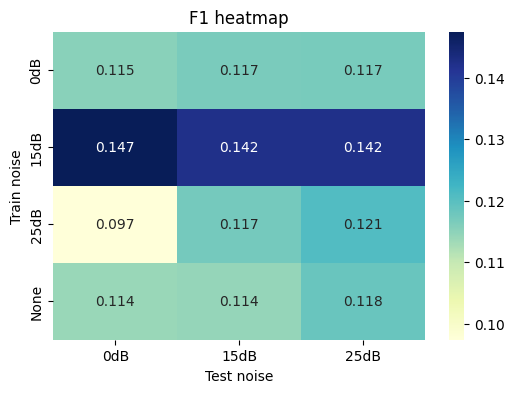

In [11]:
import seaborn as sns
pivot = df.pivot(index="train", columns="test", values="F1")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("F1 heatmap")
plt.ylabel("Train noise")
plt.xlabel("Test noise")
plt.show()


In [1]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("agkphysics/AudioSet", "balanced")

/jumbo/graphmind/yinghao/miniconda3/envs/ASL1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torchaudio

In [2]:
import torchaudio
import torch
import datasets
import io
import numpy as np

# Mel 变换器
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    win_length=400,
    hop_length=160,
    n_mels=64,
)

amp_to_db = torchaudio.transforms.AmplitudeToDB()

# 统一 mel 时间长度
MAX_FRAMES = 1024   # 可调整

def pad_or_trim(feature, max_len=MAX_FRAMES):
    """
    输入: feature shape (64, T)
    输出: 固定 (64, max_len)
    """
    T = feature.shape[1]

    if T == max_len:
        return feature

    if T > max_len:
        return feature[:, :max_len]

    # pad
    pad_width = max_len - T
    pad = np.zeros((feature.shape[0], pad_width), dtype=feature.dtype)
    return np.concatenate([feature, pad], axis=1)


def preprocess(batch):
    audio = batch["audio"]

    # audio 始终包含 bytes
    waveform, sr = torchaudio.load(io.BytesIO(audio["bytes"]))   # (C, T)

    # 转 mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # resample
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    # mel
    mel = mel_transform(waveform)    # (1, 64, T)
    logmel = amp_to_db(mel)[0].numpy()  # (64, T)

    # 固定长度
    logmel = pad_or_trim(logmel, MAX_FRAMES)

    # 返回
    batch["log_mel"] = logmel  # shape (64, MAX_FRAMES)
    return batch


# 强制 audio 用 bytes
ds = ds.cast_column("audio", datasets.Audio(decode=False))

# 运行
ds_logmel = ds.map(preprocess)


Map: 100%|██████████| 17141/17141 [10:28<00:00, 27.28 examples/s]  


In [3]:
for split in ['train', 'test']:
    for i in range(len(ds_logmel[split])):
        ds_logmel[split][i]['log_mel'] = torch.tensor(ds_logmel[split][i]['log_mel'])

In [41]:
from collections import defaultdict

inverted_index = defaultdict(list)

train_ds = ds_logmel['train']

for i in range(len(train_ds)):
    labels = train_ds[i]['human_labels']   # 可能是 list[str]
    for lb in labels:
        inverted_index[lb].append(i)


In [56]:
for i in inverted_index['Thunder']:
    # if 'Wind' in train_ds[i]['human_labels']:
    #     print(i)
    print(train_ds[i]['human_labels'])

['Rain', 'Raindrop', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Rustle', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rustle', 'Thunderstorm', 'Thunder']
['Rain', 'Raindrop', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunder']
['Rain', 'Raindrop', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Rustle', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rustle', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Rustle', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rai

In [4]:
from collections import defaultdict
import itertools

train_ds = ds_logmel['train']

# 1. 收集所有标签
all_labels = set()
for i in range(len(train_ds)):
    for lb in train_ds[i]["human_labels"]:
        all_labels.add(lb)
all_labels = sorted(all_labels)

# 2. 初始化矩阵
overlap = {a: defaultdict(int) for a in all_labels}

# 3. 统计重叠
for i in range(len(train_ds)):
    labels = train_ds[i]["human_labels"]
    # 每条样本里的标签两两组合
    for a, b in itertools.combinations(sorted(labels), 2):
        overlap[a][b] += 1
        overlap[b][a] += 1  # 对称矩阵


In [59]:
overlap

{'A capella': defaultdict(int,
             {'Choir': 10,
              'Singing': 25,
              'Tap': 1,
              'Vocal music': 13,
              'Music': 29,
              'Song': 5,
              'Chant': 2,
              'Gospel music': 5,
              'Christian music': 2,
              'Humming': 2,
              'Bowed string instrument': 1,
              'Classical music': 1,
              'Musical instrument': 1,
              'Violin, fiddle': 1,
              'Happy music': 1,
              'Speech': 1}),
 'Accelerating, revving, vroom': defaultdict(int,
             {'Medium engine (mid frequency)': 19,
              'Heavy engine (low frequency)': 11,
              'Vehicle': 39,
              'Engine knocking': 3,
              'Car': 25,
              'Engine': 15,
              'Keys jangling': 1,
              'Motor vehicle (road)': 8,
              'Engine starting': 4,
              'Idling': 6,
              'Inside, large room or hall': 1,
            

In [5]:
import datasets
ds = ds.cast_column("audio", datasets.Audio(decode=False))

In [15]:
for i in range(len(ds['train'])):
    if 'bytes' not in ds['train'][i]['audio']:
        print(i)

In [14]:
'bytes' in ds['train'][0]['audio']

True

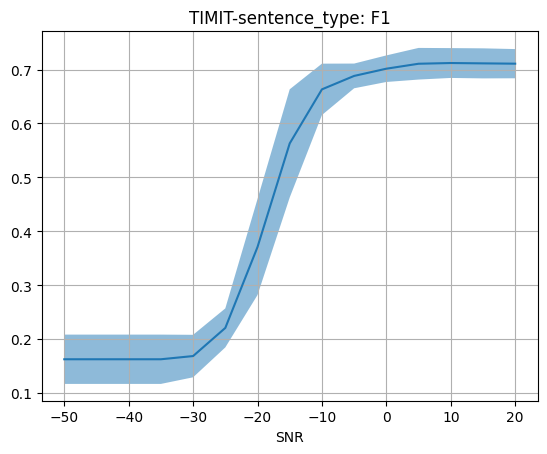

In [77]:
# Baseline: train on clean, test on noise
import yaml
import os
import matplotlib.pyplot as plt 
import numpy as np
data_dict = {}
for seed in [0, 1, 2]:
    for snr in range(-50, 25, 5):
        path = (
            f"results/test/training/"
            f"TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_"
            f"StaticGaussian({snr})_{seed}/_test/test_holistic.yaml"
        )

        with open(path, "r") as f:
            data = yaml.safe_load(f)   # ← 正确方式
            # print(snr, data['f1']['all'])
            if snr in data_dict:
                data_dict[snr].append(data['f1']['all'])
            else:
                data_dict[snr] = [data['f1']['all']]

x = list(data_dict.keys())
mean_list = np.array([np.mean(data_dict[s]) for s in x])
std_list = np.array([np.std(data_dict[s]) for s in x])
plt.plot(x, mean_list)
plt.title("TIMIT-sentence_type: F1")
plt.grid()
plt.xlabel("SNR")
plt.fill_between(x, mean_list-std_list, mean_list+std_list, alpha=0.5)

In [79]:
for i in range(-30, 5, 5):
    print(i)

-30
-25
-20
-15
-10
-5
0
